<a href="https://colab.research.google.com/github/Shafique1234567890/Simple-Neural-Layer-Implementation/blob/main/NeuralNetworkACC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train shape: (593, 21)
Test shape : (149, 21)
Train samples      : 474
Validation samples : 119
Test samples       : 149


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,569 (53.00 KB)

 Trainable params: 13,569 (53.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.5696 - loss: 0.6852 - val_accuracy: 0.7227 - val_loss: 0.6688
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6857 - loss: 0.6370 - val_accuracy: 0.7143 - val_loss: 0.6204
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7532 - loss: 0.5653 - val_accuracy: 0.7311 - val_loss: 0.5568
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8122 - loss: 0.4860 - val_accuracy: 0.7479 - val_loss: 0.5063
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7975 - loss: 0.4677 - val_accuracy: 0.7563 - val_loss: 0.4848
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8291 - loss: 0.4329 - val_accuracy: 0.7479 - val_loss: 0.4738
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8418 - loss: 0.3876 - val_accuracy: 0.7731 - val_loss: 0.4612
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8481 - loss: 0.3731 - val_accuracy: 0.773

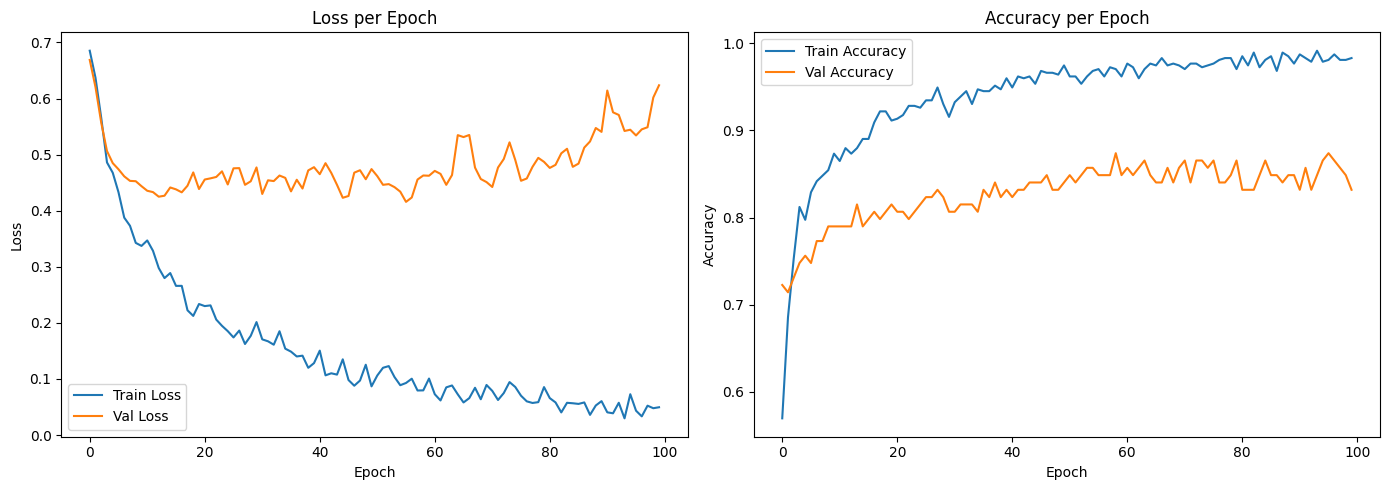


Metric                         Train   Validation       Test
------------------------------------------------------------
Loss                          0.0065       0.6236     0.6255
Accuracy                      0.9979       0.8319     0.8456
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Classification Report (Test Set):
              precision    recall  f1-score   support

     Class 0       0.90      0.79      0.84        78
     Class 1       0.80      0.90      0.85        71

    accuracy                           0.85       149
   macro avg       0.85      0.85      0.85       149
weighted avg       0.85      0.85      0.85       149

Confusion Matrix:
[[62 16]
 [ 7 64]]


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

train_df = pd.read_csv('/content/CLASS-1_AAC_train (1).csv')
test_df  = pd.read_csv('/content/CLASS-1_AAC_test (1).csv')
print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
train_df.head()
X = train_df.drop('classifier', axis=1).values
y = train_df['classifier'].values

X_test_final = test_df.drop('classifier', axis=1).values
y_test_final = test_df['classifier'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train      = scaler.fit_transform(X_train)
X_val        = scaler.transform(X_val)
X_test_final = scaler.transform(X_test_final)

print(f'Train samples      : {X_train.shape[0]}')
print(f'Validation samples : {X_val.shape[0]}')
print(f'Test samples       : {X_test_final.shape[0]}')
# ---------- Hyperparameters ----------
EPOCHS      = 100
BATCH_SIZE  = 32
LR          = 0.001
# -------------------------------------

tf.random.set_seed(42)

model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.2),
    Dense(32,  activation='relu'),
    Dropout(0.2),
    Dense(16,  activation='relu'),
    Dense(1,   activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=LR),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss per Epoch')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Accuracy per Epoch')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()
train_loss, train_acc = model.evaluate(X_train,      y_train,      verbose=0)
val_loss,   val_acc   = model.evaluate(X_val,        y_val,        verbose=0)
test_loss,  test_acc  = model.evaluate(X_test_final, y_test_final, verbose=0)

print(f'\n{"Metric":<25} {"Train":>10} {"Validation":>12} {"Test":>10}')
print('-' * 60)
print(f'{"Loss":<25} {train_loss:>10.4f} {val_loss:>12.4f} {test_loss:>10.4f}')
print(f'{"Accuracy":<25} {train_acc:>10.4f} {val_acc:>12.4f} {test_acc:>10.4f}')
y_pred_prob = model.predict(X_test_final)
y_pred      = (y_pred_prob >= 0.5).astype(int).flatten()

print('Classification Report (Test Set):')
print(classification_report(y_test_final, y_pred, target_names=['Class 0', 'Class 1']))

print('Confusion Matrix:')
print(confusion_matrix(y_test_final, y_pred))